In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

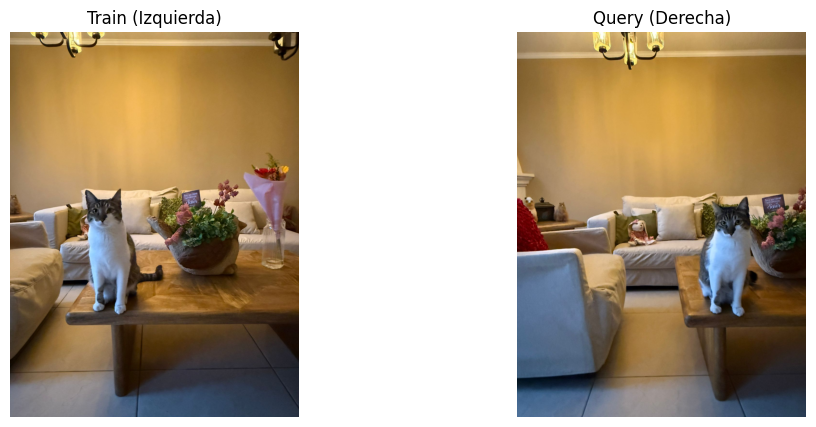

In [4]:
img_train = cv2.imread("left.jpeg")   # Imagen Izquierda (Base)
img_query = cv2.imread("right.jpeg")  # Imagen Derecha (Mover)

# Convertir a RGB para visualizar con matplotlib
img_train_rgb = cv2.cvtColor(img_train, cv2.COLOR_BGR2RGB)
img_query_rgb = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Train (Izquierda)")
plt.imshow(img_train_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Query (Derecha)")
plt.imshow(img_query_rgb)
plt.axis("off")
plt.show()

In [5]:
orb = cv2.ORB_create(4000)

kp1, des1 = orb.detectAndCompute(img_train, None)
kp2, des2 = orb.detectAndCompute(img_query, None)

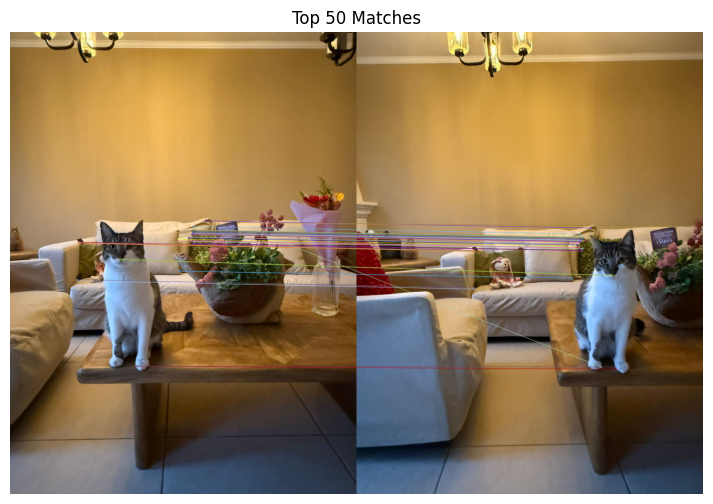

In [6]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

# Visualizar matches
img_matches = cv2.drawMatches(img_train, kp1,
                              img_query, kp2,
                              matches[:50], None,
                              flags=2)

plt.figure(figsize=(15,6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Top 50 Matches")
plt.axis("off")
plt.show()

In [7]:
pts_train = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts_query = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(pts_query, pts_train, cv2.RANSAC, 5.0)

print("Homografía:\n", H)

Homografía:
 [[ 1.04827019e+00 -1.92296975e-01 -5.73536974e+01]
 [ 7.63783556e-02  8.60659502e-01 -1.15700104e+00]
 [ 9.09059594e-05 -1.33327538e-04  1.00000000e+00]]


La matriz de homografía estimada presenta componentes proyectivas pequeñas (del orden de 10⁻⁴), lo que indica estabilidad geométrica. La traslación horizontal estimada fue de aproximadamente 57 píxeles, consistente con el movimiento realizado durante la captura.

# TASK 2

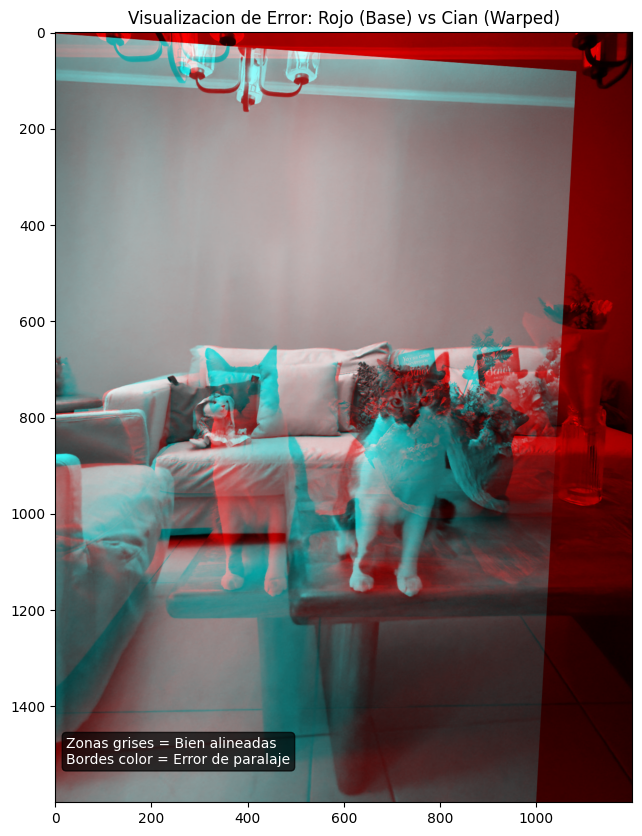

True

In [12]:
h, w, _ = img_train.shape
img_warped = cv2.warpPerspective(img_query, H, (w, h))

# 1. Convertir ambas imágenes a escala de grises para que el color solo represente el error
gray_base = cv2.cvtColor(img_train, cv2.COLOR_BGR2GRAY)
gray_warped = cv2.cvtColor(img_warped, cv2.COLOR_BGR2GRAY)

# 2. Crear una imagen vacia (ceros) con 3 canales (RGB)
anaglifo = np.zeros((h, w, 3), dtype=np.uint8)

# 3. Asignar canales:
# Canal Rojo (R) = Imagen Base (Izquierda)
anaglifo[:, :, 0] = gray_base 

# Canales Verde (G) + Azul (B) = Cian = Imagen Warped (Derecha transformada)
anaglifo[:, :, 1] = gray_warped
anaglifo[:, :, 2] = gray_warped

plt.figure(figsize=(15, 10))
plt.imshow(anaglifo)
plt.title("Visualizacion de Error: Rojo (Base) vs Cian (Warped)")
plt.annotate('Zonas grises = Bien alineadas\nBordes color = Error de paralaje', 
             xy=(0.02, 0.05), xycoords='axes fraction', color='white', 
             bbox=dict(boxstyle="round", fc="black", alpha=0.7))
plt.axis("on")
plt.show()

cv2.imwrite("error_visualizacion.png", cv2.cvtColor(anaglifo, cv2.COLOR_RGB2BGR))

In [16]:
import pandas as pd

datos = {
    "GATO (Cercano)": {
        "distancia": "~0.5 m",
        "x_rojo": 320,  
        "x_cian": 620  
    },
    "SILLON (Medio)": {
        "distancia": "~1.5 m",
        "x_rojo": 300,  
        "x_cian": 280  
    },
    "PARED (Fondo)": {
        "distancia": ">2.0 m",
        "x_rojo": 40,  
        "x_cian": 100 
    }
}

filas = []
for obj, info in datos.items():
    disparidad = abs(info["x_rojo"] - info["x_cian"])
    filas.append([obj, info["distancia"], info["x_rojo"], info["x_cian"], round(disparidad, 2)])

df_final = pd.DataFrame(filas, columns=[
    "Objeto", 
    "Distancia Real Estimada", 
    "Coordenada X Fantasma 1", 
    "Coordenada X Fantasma 2", 
    "Disparidad (|x1-x2|) en pixeles"
])

print("\n--- TABLA DE RESULTADOS LABORATIO 5 ---")
display(df_final)


--- TABLA DE RESULTADOS LABORATIO 5 ---


,Objeto,Distancia Real Estimada,Coordenada X Fantasma 1,Coordenada X Fantasma 2,Disparidad (|x1-x2|) en pixeles
0,GATO (Cercano),~0.5 m,320,620,300
1,SILLON (Medio),~1.5 m,300,280,20
2,PARED (Fondo),>2.0 m,40,100,60
